In [1]:
import sys
from pathlib import Path

current = Path().resolve()

for parent in [current] + list(current.parents):
    if (parent / "backend").exists():
        sys.path.append(str(parent))
        print("Project root found:", parent)
        break

Project root found: D:\Projects\Thesis\sem10\pipeline


In [2]:
import pandas as pd
from backend.config import settings

DATASET_PATH = settings.RECON_OUTPUT_FOLDER / "training_dataset.csv"

df = pd.read_csv(DATASET_PATH)

# convert labels
df["label"] = df["label"].map({"n": 0, "d": 1})

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (13812, 12)


,area_um2,perimeter,circularity,elongation,mean_phase,std_phase,min_phase,max_phase,MCH_surface_density,optical_volume,label,sample
0,60.83,318.066017,0.755602,1.486496,0.399327,0.320484,-1.007774,1.244906,2.235011,24.291042,1,a10_1_d__r6_1_d
1,65.19,376.722871,0.577227,2.791146,0.302766,0.277780,-0.569725,0.691885,1.694568,19.737339,1,a10_1_d__r6_1_d
2,225.22,565.688384,0.884428,1.145016,0.529078,0.286889,-0.516483,1.152088,2.961224,119.159002,1,a10_1_d__r6_1_d
3,227.42,575.813275,0.861936,1.077949,1.134185,0.380293,-0.244228,1.960601,6.347976,257.936370,1,a10_1_d__r6_1_d
4,268.39,653.381818,0.790027,1.335597,0.659878,0.329374,-0.556560,1.317423,3.693300,177.104517,1,a10_1_d__r6_1_d


In [3]:
"mean_phase" in df.columns
df["mean_phase"].head()

0    0.399327
1    0.302766
2    0.529078
3    1.134185
4    0.659878
Name: mean_phase, dtype: float64

In [4]:
import numpy as np

df["mean_phase"] = pd.to_numeric(df["mean_phase"], errors="coerce")
df = df.dropna(subset=["mean_phase"])

print("Dataset size after cleaning:", df.shape)

Dataset size after cleaning: (13812, 12)


Matplotlib is building the font cache; this may take a moment.


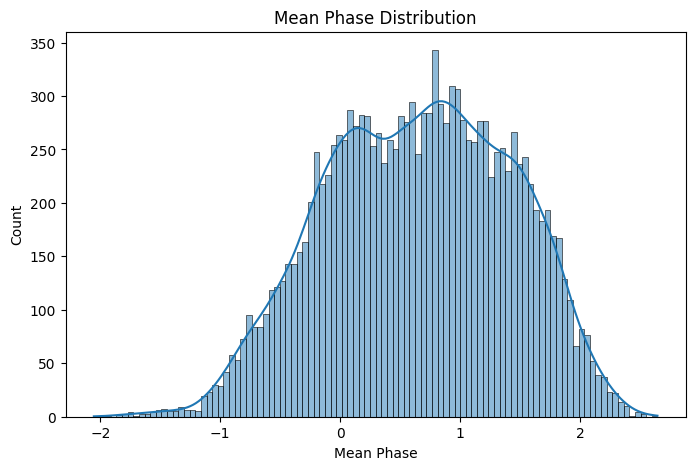

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(df["mean_phase"], bins=100, kde=True)

plt.title("Mean Phase Distribution")
plt.xlabel("Mean Phase")
plt.ylabel("Count")

plt.show()

<Axes: xlabel='mean_phase', ylabel='Count'>

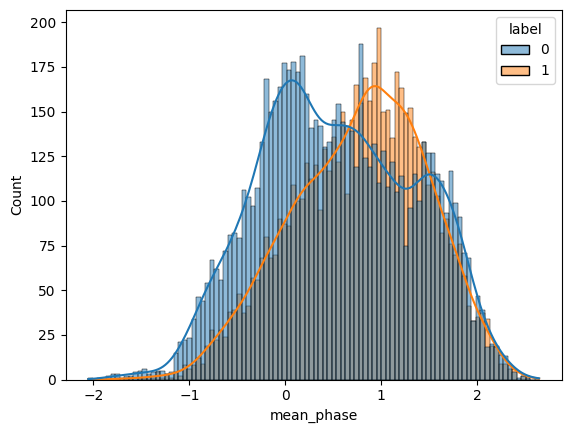

In [6]:
import seaborn as sns

sns.histplot(data=df, x="mean_phase", hue="label", bins=100, kde=True)

In [7]:
print(df["mean_phase"].min(), df["mean_phase"].max())

-2.0542111 2.6462543


In [8]:
image_stats = df.groupby("sample").agg({
    "std_phase": "mean",
    "mean_phase": "mean",
    "area_um2": "count"
}).rename(columns={"area_um2": "cell_count"})

image_stats.head()

,std_phase,mean_phase,cell_count
sample,,,
a10_1_d__r6_1_d,0.309043,0.574522,54
a10_1_n__r14_1_n,0.347844,1.757639,30
a10_2_d__r5_2_d,0.278730,0.046373,49
a10_2_n__r8_2_n,0.174917,-1.225266,16
a11_1_d__r1_1_d,0.324229,-0.060256,60


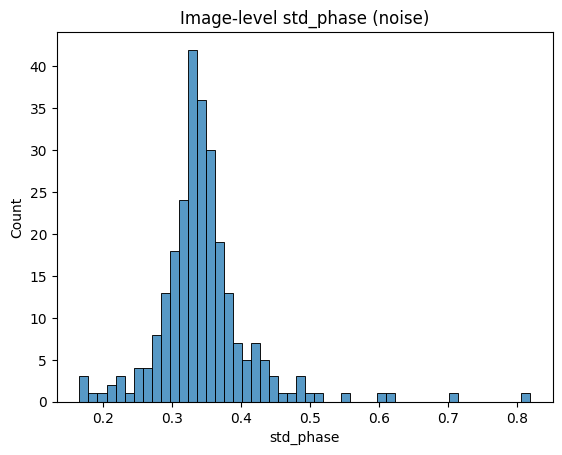

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(image_stats["std_phase"], bins=50)
plt.title("Image-level std_phase (noise)")
plt.show()

In [10]:
std_thresh = 0.45

good_images = image_stats[
    image_stats["std_phase"] <= std_thresh
].index

df_clean = df[df["sample"].isin(good_images)]

print("Original images:", len(image_stats))
print("Remaining images:", len(good_images))

print("Original rows:", len(df))
print("After filtering:", len(df_clean))

Original images: 261
Remaining images: 248
Original rows: 13812
After filtering: 13167


In [11]:
bad_images = image_stats[
    image_stats["std_phase"] > std_thresh
]

print("Bad images removed:", len(bad_images))
bad_images.sort_values("std_phase", ascending=False).head(10)

Bad images removed: 13


,std_phase,mean_phase,cell_count
sample,,,
a51_2_n__r3_2_n,0.818726,1.365035,1
a1_1_d__r6_1_d,0.714072,0.470022,9
a51_2_d__r11_2_d,0.610016,0.924043,79
a13_1_d__r7_1_d,0.609576,0.758262,31
a56_2_d__r5_2_d,0.548245,1.033485,54
a38_1_d__r2_1_d,0.515836,1.195353,81
a38_2_d__r12_2_d,0.493941,0.346879,46
a44_1_d__r4_1_d,0.492130,0.395514,84
a4_1_n__r14_1_n,0.490358,1.509135,36


<Axes: xlabel='mean_phase', ylabel='Count'>

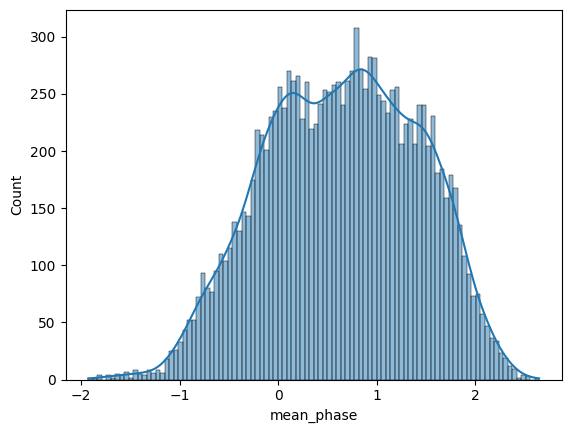

In [12]:
sns.histplot(df_clean["mean_phase"], bins=100, kde=True)

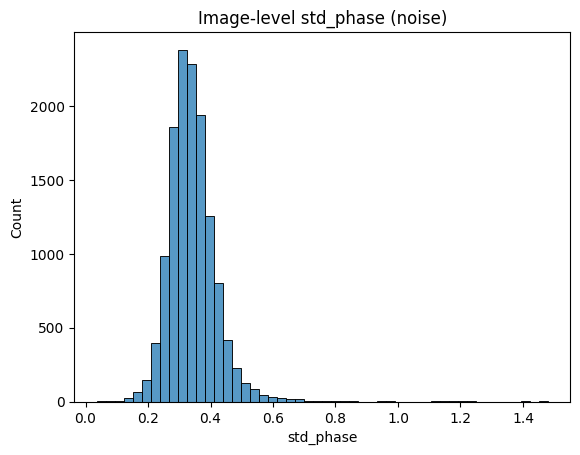

In [13]:
sns.histplot(df_clean["std_phase"], bins=50)
plt.title("Image-level std_phase (noise)")
plt.show()

In [14]:
df_clean = df_clean[df_clean["area_um2"] > 20]

In [15]:
features = [
    "area_um2",
    "perimeter",
    "circularity",
    "elongation",
    "mean_phase",
    "std_phase",
    "min_phase",
    "max_phase",
    "MCH_surface_density",
    "optical_volume"
]

# standardize
df_clean[features] = (
    df_clean[features] - df_clean[features].mean()
) / df_clean[features].std()

In [16]:
from sklearn.model_selection import train_test_split

unique_images = df_clean["sample"].unique()

train_imgs, test_imgs = train_test_split(
    unique_images,
    test_size=0.2,
    random_state=42
)

train_df = df_clean[df_clean["sample"].isin(train_imgs)]
test_df  = df_clean[df_clean["sample"].isin(test_imgs)]

In [17]:
X_train = train_df[features].values
y_train = train_df["label"].values

X_test = test_df[features].values
y_test = test_df["label"].values

In [22]:
from tabpfn import TabPFNClassifier

clf = TabPFNClassifier(
    n_estimators=16,
    softmax_temperature=0.8,
    balance_probabilities=True,
    average_before_softmax=True,
    ignore_pretraining_limits=True,
    random_state=42
)
clf.fit(X_train, y_train)

d:\Projects\Thesis\sem10\pipeline\thenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,n_estimators,16
,categorical_features_indices,None
,softmax_temperature,0.8
,balance_probabilities,True
,average_before_softmax,True
,model_path,'auto'
,device,'auto'
,ignore_pretraining_limits,True
,inference_precision,'auto'
,fit_mode,'fit_preprocessors'
,memory_saving_mode,'auto'


In [23]:
from sklearn.metrics import classification_report

y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.81      0.81      1543
           1       0.74      0.72      0.73      1114

    accuracy                           0.77      2657
   macro avg       0.77      0.77      0.77      2657
weighted avg       0.77      0.77      0.77      2657



In [24]:
y_proba = clf.predict_proba(X_test)[:, 1]  # probability of class 1
test_df = test_df.copy()
test_df["cell_prob"] = y_proba
test_df["cell_pred"] = (y_proba > 0.5).astype(int)

In [25]:
image_preds = test_df.groupby("sample").agg({
    "cell_prob": "mean",
    "label": "first"   # true label (same for all cells in image)
}).reset_index()

image_preds["image_pred"] = (image_preds["cell_prob"] > 0.4).astype(int)

In [26]:
from sklearn.metrics import classification_report

print(classification_report(
    image_preds["label"],
    image_preds["image_pred"]
))

              precision    recall  f1-score   support

           0       0.92      0.88      0.90        25
           1       0.88      0.92      0.90        25

    accuracy                           0.90        50
   macro avg       0.90      0.90      0.90        50
weighted avg       0.90      0.90      0.90        50



In [27]:
import joblib

joblib.dump(clf, "../models/tabpfn_model.pkl")
joblib.dump(features, "../models/features.pkl")
joblib.dump(0.4, "../models/threshold.pkl")

metadata = {
    "model": "TabPFN",
    "threshold": 0.4,
    "features": features,
    "notes": "image-wise probability averaging"
}

joblib.dump(metadata, "../models/metadata.pkl")

['../models/metadata.pkl']

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import xgboost as xgb

In [19]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": xgb.XGBClassifier(
        n_estimators=100,
        eval_metric="logloss",
        use_label_encoder=False
    )
}

In [20]:
results = {}

for name, model in models.items():
    print(f"\n🔹 {name}")
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    report = classification_report(y_test, y_pred, output_dict=True)
    print(classification_report(y_test, y_pred))
    
    results[name] = report


🔹 Logistic Regression
              precision    recall  f1-score   support

           0       0.75      0.78      0.76      1543
           1       0.68      0.65      0.66      1114

    accuracy                           0.72      2657
   macro avg       0.71      0.71      0.71      2657
weighted avg       0.72      0.72      0.72      2657


🔹 Random Forest
              precision    recall  f1-score   support

           0       0.76      0.83      0.79      1543
           1       0.73      0.65      0.68      1114

    accuracy                           0.75      2657
   macro avg       0.75      0.74      0.74      2657
weighted avg       0.75      0.75      0.75      2657


🔹 XGBoost
              precision    recall  f1-score   support

           0       0.77      0.81      0.79      1543
           1       0.72      0.67      0.69      1114

    accuracy                           0.75      2657
   macro avg       0.74      0.74      0.74      2657
weighted avg       0.75

d:\Projects\Thesis\sem10\pipeline\thenv\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:53:59] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [21]:
import pandas as pd

for name, model in models.items():
    print(f"\n🔸 Image-level: {name}")
    
    y_proba = model.predict_proba(X_test)[:, 1]
    
    temp_df = test_df.copy()
    temp_df["cell_prob"] = y_proba

    image_preds = temp_df.groupby("sample").agg({
        "cell_prob": "mean",
        "label": "first"
    }).reset_index()

    image_preds["image_pred"] = (image_preds["cell_prob"] > 0.4).astype(int)

    print(classification_report(
        image_preds["label"],
        image_preds["image_pred"]
    ))


🔸 Image-level: Logistic Regression
              precision    recall  f1-score   support

           0       0.86      0.76      0.81        25
           1       0.79      0.88      0.83        25

    accuracy                           0.82        50
   macro avg       0.82      0.82      0.82        50
weighted avg       0.82      0.82      0.82        50


🔸 Image-level: Random Forest
              precision    recall  f1-score   support

           0       0.87      0.80      0.83        25
           1       0.81      0.88      0.85        25

    accuracy                           0.84        50
   macro avg       0.84      0.84      0.84        50
weighted avg       0.84      0.84      0.84        50


🔸 Image-level: XGBoost
              precision    recall  f1-score   support

           0       0.91      0.84      0.88        25
           1       0.85      0.92      0.88        25

    accuracy                           0.88        50
   macro avg       0.88      0.88     